In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# ============================================
# COMPLETE CNN IMAGE CLASSIFICATION SOLUTION
# Worksheet 5: End-to-End CNN Model for Image Classification
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import random
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Define paths
train_dir = "/content/drive/MyDrive/Level 6 AI ML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/Level 6 AI ML/FruitinAmazon/test"

print(f"TensorFlow version: {tf.__version__}")
print("=" * 60)

TensorFlow version: 2.19.0


In [21]:
import zipfile
import os
from tqdm import tqdm

def extract_zip_with_progress(zip_path, extract_to='/content'):
    """Extract ZIP file with a progress bar."""
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        total = len(members)

        print(f"📦 Found {total} files | Size: {sum(m.file_size for m in members) / 1e6:.1f} MB")

        for member in tqdm(members, desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

    print(f"Done! Files saved to: {extract_to}")

# Usage
extract_zip_with_progress('/content/drive/MyDrive/Level 6 AI ML/FruitinAmazon.zip', '/content/drive/MyDrive/Level 6 AI ML/Week5')

📦 Found 120 files | Size: 1.2 MB


Extracting: 100%|██████████| 120/120 [00:01<00:00, 103.59file/s]

Done! Files saved to: /content/drive/MyDrive/Level 6 AI ML/Week5


TASK 1: Data Understanding and Visualization
Found 6 classes: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


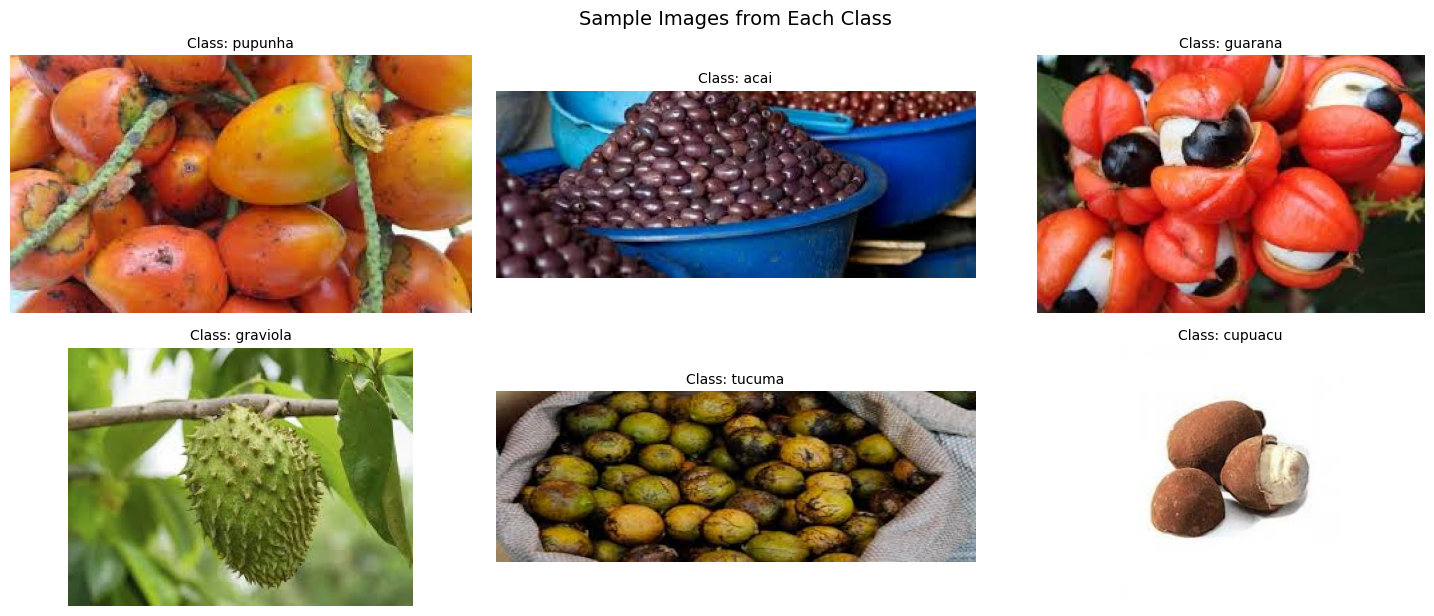


--- OBSERVATIONS ---
1. Dataset contains 6 different fruit classes:
   1. pupunha
   2. acai
   3. guarana
   4. graviola
   5. tucuma
   6. cupuacu
2. Images are in color (RGB) format
3. Different classes may have varying number of images
4. Images may have different sizes and orientations


In [22]:
# ============================================
# TASK 1: Data Understanding and Visualization
# ============================================

print("=" * 60)
print("TASK 1: Data Understanding and Visualization")
print("=" * 60)

# 1.1 Load and visualize images from dataset

# Get list of class directories from train folder
class_dirs = [d for d in os.listdir(train_dir)
              if os.path.isdir(os.path.join(train_dir, d))]
print(f"Found {len(class_dirs)} classes: {class_dirs}")

# Calculate grid dimensions for display
n_classes = len(class_dirs)
n_rows = 2
n_cols = (n_classes + 1) // 2  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
if n_rows == 1 and n_cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, class_name in enumerate(class_dirs):
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    if images:
        random_image = random.choice(images)
        image_path = os.path.join(class_path, random_image)
        img = Image.open(image_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Class: {class_name}", fontsize=10)
        axes[idx].axis('off')
    else:
        axes[idx].set_title(f"Class: {class_name} (No images)", fontsize=10)
        axes[idx].axis('off')

# Hide any unused subplots
for idx in range(len(class_dirs), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle("Sample Images from Each Class", fontsize=14, y=1.02)
plt.show()

print("\n--- OBSERVATIONS ---")
print(f"1. Dataset contains {len(class_dirs)} different fruit classes:")
for i, cls in enumerate(class_dirs, 1):
    print(f"   {i}. {cls}")
print("2. Images are in color (RGB) format")
print("3. Different classes may have varying number of images")
print("4. Images may have different sizes and orientations")

In [24]:
# ============================================
# TASK 1.2: Check for Corrupted Images
# ============================================

print("\n" + "=" * 60)
print("TASK 1.2: Checking for Corrupted Images")
print("=" * 60)

def check_and_remove_corrupted_images(directory):
    """Check for corrupted images and remove them"""
    corrupted_images = []

    if not os.path.exists(directory):
        print(f"Directory not found: {directory}")
        return corrupted_images

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue

        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                image_path = os.path.join(class_path, image_file)

                try:
                    # Attempt to open and verify the image
                    with Image.open(image_path) as img:
                        img.verify()  # Verify integrity

                    # Additional check: try to load the image fully
                    with Image.open(image_path) as img:
                        img.load()

                except (IOError, SyntaxError, OSError, Image.DecompressionBombError) as e:
                    print(f"Corrupted image found: {image_path}")
                    print(f"Error: {e}")

                    # Remove the corrupted image
                    try:
                        os.remove(image_path)
                        print(f" Removed corrupted image: {image_path}")
                        corrupted_images.append(image_path)
                    except Exception as remove_error:
                        print(f" Could not remove {image_path}: {remove_error}")

    return corrupted_images

# Check train directory
print("Checking training directory...")
corrupted_train = check_and_remove_corrupted_images(train_dir)

# Check test directory if it exists
if os.path.exists(test_dir):
    print("\nChecking test directory...")
    corrupted_test = check_and_remove_corrupted_images(test_dir)
else:
    corrupted_test = []
    print("\nTest directory not found, skipping...")

if len(corrupted_train) == 0 and len(corrupted_test) == 0:
    print("\n No Corrupted Images Found")
else:
    print(f"\n Found and removed {len(corrupted_train)} corrupted images from train")
    print(f" Found and removed {len(corrupted_test)} corrupted images from test")


TASK 1.2: Checking for Corrupted Images
Checking training directory...

Checking test directory...

 No Corrupted Images Found


In [25]:
# ============================================
# TASK 2: Loading and Preprocessing Image Data (FIXED)
# ============================================

print("\n" + "=" * 60)
print("TASK 2: Loading and Preprocessing Image Data")
print("=" * 60)

# Define parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Create preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0, 1]

# Create training dataset (FIRST, before applying map)
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Create validation dataset (FIRST, before applying map)
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# STORE class_names BEFORE applying map (this is important!)
class_names = train_ds_raw.class_names
num_classes = len(class_names)

print(f"\n Found {num_classes} classes: {class_names}")

# NOW apply normalization to datasets
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Load test dataset if available
if os.path.exists(test_dir):
    test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(img_height, img_width),
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=False
    )
    test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
    print(f"\n Test dataset loaded with {len(test_ds_raw.class_names)} classes")
    # Verify test classes match training classes
    if test_ds_raw.class_names != class_names:
        print("Warning: Test set classes differ from training set!")
else:
    test_ds = None
    print("\n No separate test directory found. Will use validation set for testing.")

# Display sample batch information
print("\n Dataset Information:")
print(f"  Training batches: {len(train_ds)}")
print(f"  Validation batches: {len(val_ds)}")
if test_ds:
    print(f"  Test batches: {len(test_ds)}")

# Display sample batch shapes
for images, labels in train_ds.take(1):
    print(f"\n Sample batch shapes:")
    print(f"  Images shape: {images.shape}")
    print(f"  Labels shape: {labels.shape}")
    print(f"  Pixel value range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")
    print(f"  First 5 labels: {labels[:5].numpy()}")

# Verify normalization worked correctly
print(f"\n Normalization verified: Pixel values are now in range [0, 1]")


TASK 2: Loading and Preprocessing Image Data
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

 Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 30 files belonging to 6 classes.

 Test dataset loaded with 6 classes

 Dataset Information:
  Training batches: 3
  Validation batches: 1
  Test batches: 1

 Sample batch shapes:
  Images shape: (32, 128, 128, 3)
  Labels shape: (32,)
  Pixel value range: [0.00, 1.00]
  First 5 labels: [0 5 0 0 4]

 Normalization verified: Pixel values are now in range [0, 1]


In [26]:
# ============================================
# TASK 3 - CNN Architecture
# ============================================

print("\n" + "=" * 60)
print("TASK 3: Implementing CNN Architecture")
print("=" * 60)

# Build the CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

total_params = model.count_params()
print(f"\n Total Parameters: {total_params:,}")


TASK 3: Implementing CNN Architecture


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)


 Total Parameters: 2,116,454


In [27]:
# ============================================
# TASK 4 - Compile Model
# ============================================

print("\n" + "=" * 60)
print("TASK 4: Compiling the Model")
print("=" * 60)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")
print("  Optimizer: Adam")
print("  Loss: Sparse Categorical Crossentropy")
print("  Metrics: Accuracy")


TASK 4: Compiling the Model
 Model compiled successfully!
  Optimizer: Adam
  Loss: Sparse Categorical Crossentropy
  Metrics: Accuracy


In [28]:
# ============================================
# TASK 5 - Train Model
# ============================================

print("\n" + "=" * 60)
print("TASK 5: Training the Model")
print("=" * 60)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                      restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                                        save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=5, min_lr=1e-6, verbose=1)
]

print("Training with batch_size=16, max_epochs=250...\n")

history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print("\n Training completed!")


TASK 5: Training the Model
Training with batch_size=16, max_epochs=250...

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.1742 - loss: 1.9516
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 608ms/step - accuracy: 0.1944 - loss: 2.0293 - val_accuracy: 0.0000e+00 - val_loss: 2.2685 - learning_rate: 0.0010
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.1997 - loss: 1.7159
Epoch 2: val_accuracy improved from 0.00000 to 0.44444, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 740ms/step - accuracy: 0.2083 - loss: 1.6812 - val_accuracy: 0.4444 - val_loss: 1.5777 - learning_rate: 0.0010
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.4635 - loss: 1.4083
Epoch 3: val_accuracy improved from 0.44444 to 0.61111, saving model to best_model.keras

Epoch 3: finished 

In [29]:
# ============================================
# TASK 6 - Evaluate Model
# ============================================

print("\n" + "=" * 60)
print("TASK 6: Evaluating the Model")
print("=" * 60)

val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

if test_ds:
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
else:
    test_accuracy = val_accuracy
    print(f"Using validation accuracy as test accuracy: {test_accuracy:.4f}")


TASK 6: Evaluating the Model

Validation Accuracy: 0.8889 (88.89%)
Test Accuracy: 0.7000 (70.00%)


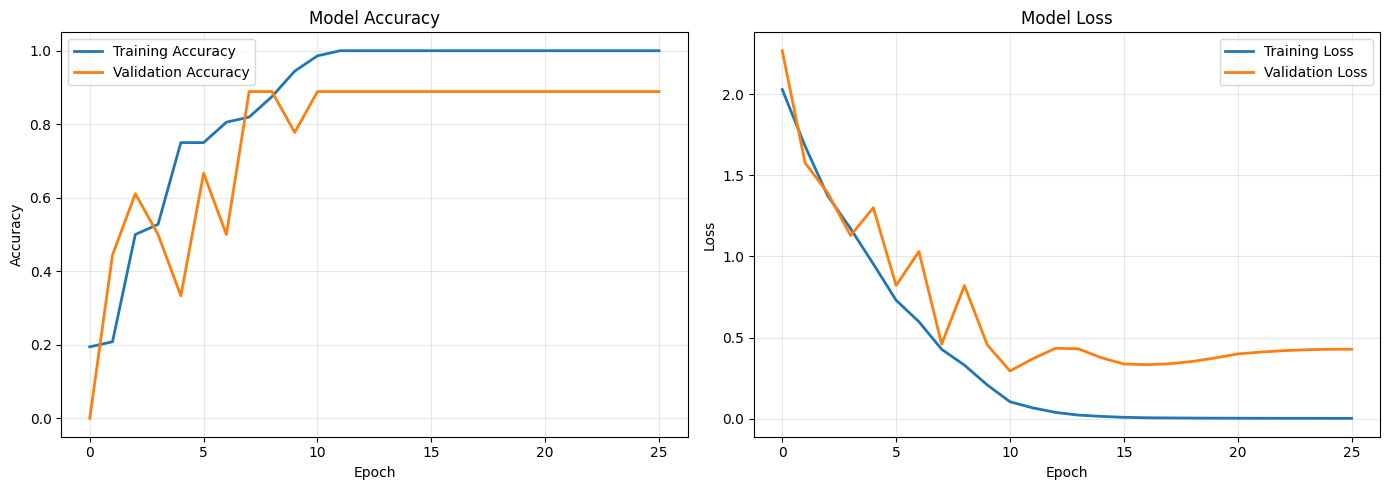

Best Validation Accuracy: 0.8889 at Epoch 8


In [33]:
# ============================================
# CELL 9: Visualization - Training History
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f} at Epoch {best_epoch}")

In [34]:
# ============================================
# CELL 10: TASK 7 - Save and Load Model
# ============================================

print("\n" + "=" * 60)
print("TASK 7: Save and Load the Model")
print("=" * 60)

model.save('fruit_classification_model.h5')
print("- Saved as 'fruit_classification_model.h5'")

loaded_model = tf.keras.models.load_model('fruit_classification_model.h5')
print("- Model loaded successfully")

loaded_val_loss, loaded_val_accuracy = loaded_model.evaluate(val_ds, verbose=0)
print(f"Loaded model accuracy: {loaded_val_accuracy:.4f}")


TASK 7: Save and Load the Model
- Saved as 'fruit_classification_model.h5'


- Model loaded successfully
Loaded model accuracy: 0.8889



TASK 8: Predictions and Classification Report

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.50      1.00      0.67         5
    graviola       1.00      0.80      0.89         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.80      0.80      0.80         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.70        30
   macro avg       0.74      0.70      0.70        30
weighted avg       0.74      0.70      0.70        30



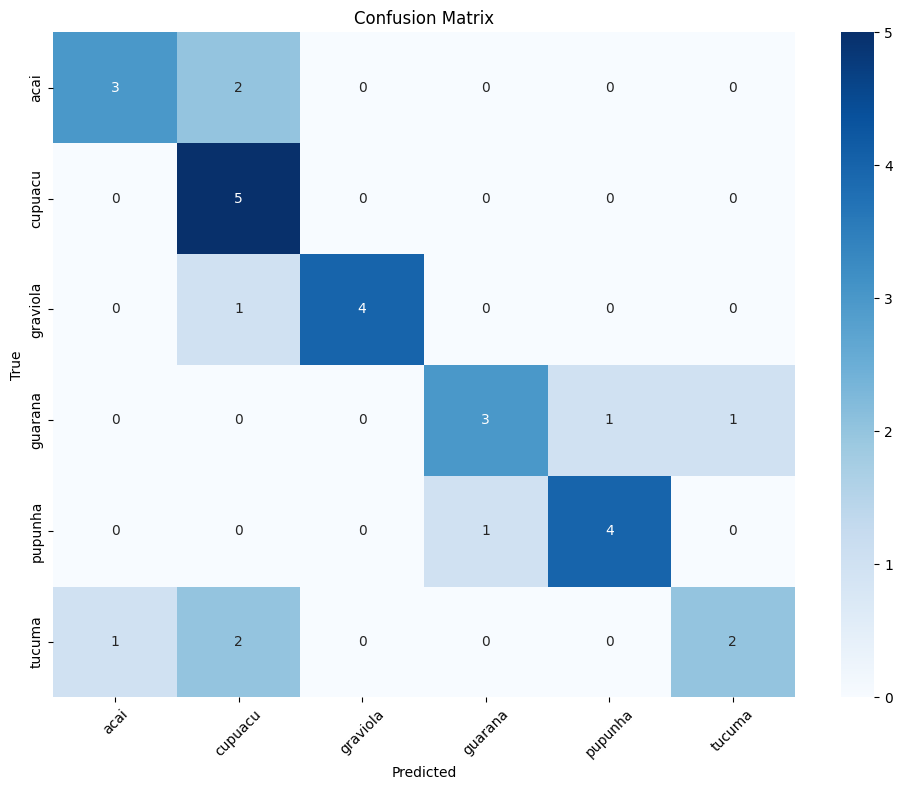


 Classification report saved to 'classification_report.txt'
 Confusion matrix saved to 'confusion_matrix.png'


In [37]:
# ============================================
# CELL 11: TASK 8 - Predictions & Classification Report
# ============================================

print("\n" + "=" * 60)
print("TASK 8: Predictions and Classification Report")
print("=" * 60)

y_true = []
y_pred = []
eval_ds = test_ds if test_ds else val_ds

for images, labels in eval_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

# Save report
with open('classification_report.txt', 'w') as f:
    f.write(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Level 6 AI ML/Week5')
plt.show()

print("\n Classification report saved to 'classification_report.txt'")
print(" Confusion matrix saved to 'confusion_matrix.png'")


Sample Predictions


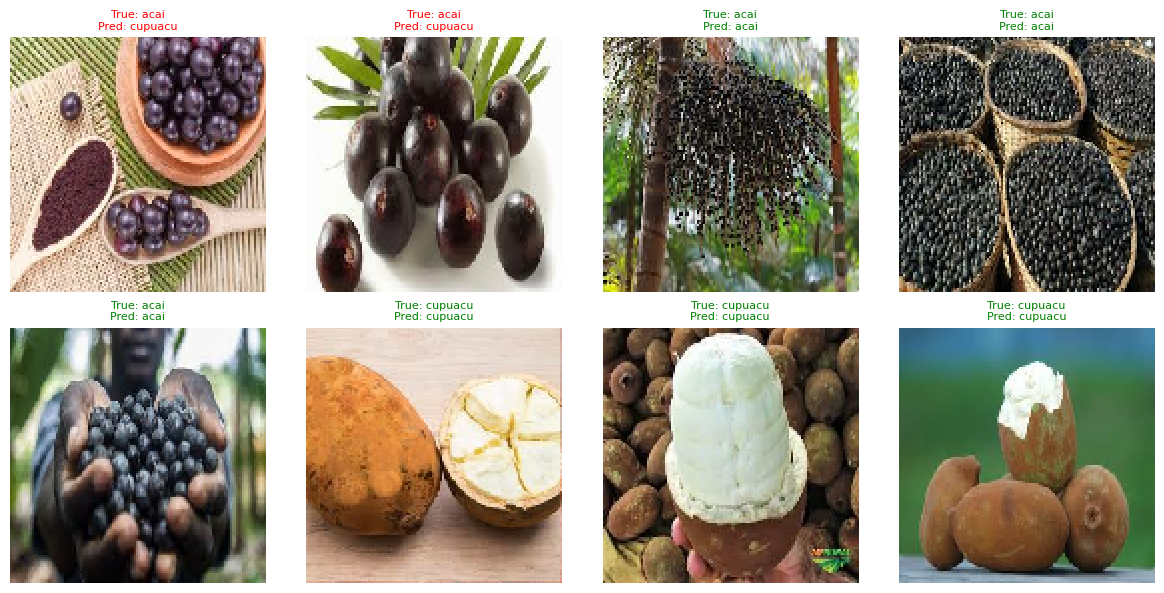


 Sample predictions saved to 'predictions_sample.png'

 ALL TASKS COMPLETED SUCCESSFULLY!


In [39]:
# ============================================
# CELL 12: Sample Predictions Display
# ============================================

print("\n" + "=" * 60)
print("Sample Predictions")
print("=" * 60)

test_images, test_labels = next(iter(eval_ds.take(1)))
predictions = loaded_model.predict(test_images[:8], verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for idx in range(8):
    axes[idx].imshow(test_images[idx])
    true_label = class_names[test_labels[idx]]
    pred_label = class_names[predicted_classes[idx]]
    color = 'green' if test_labels[idx] == predicted_classes[idx] else 'red'
    axes[idx].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=8, color=color)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Level 6 AI ML/Week5')
plt.show()

print("\n Sample predictions saved to 'predictions_sample.png'")
print("\n ALL TASKS COMPLETED SUCCESSFULLY!")